# 🏁 Fase 5: Consolidación, Intersección de Modelos y Estrategia de Negocio
**Objetivo de la Fase:** Este cuaderno actúa como el orquestador analítico final del proyecto. Su propósito es intersectar los resultados del Aprendizaje Supervisado (Probabilidad continua de fuga de clientes) con el Aprendizaje No Supervisado (Segmentación de perfiles por comportamiento). A través de este cruce multivariado, se evaluarán los trade-offs operativos, se simularán umbrales de decisión financieros y se generarán las recomendaciones estratégicas definitivas para la toma de decisiones.

In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Componentes de modelación consolidada
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

print("✅ Entorno de consolidación final cargado con éxito.")

✅ Entorno de consolidación final cargado con éxito.


## 1. Reconstrucción del Pipeline y Preparación de Matrices

In [2]:
# 1. Definición de rutas del proyecto
BASE_DIR = Path(os.getcwd()).parent
raw_path = BASE_DIR / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
if not raw_path.exists():
    raw_path = BASE_DIR / "data" / "Raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df_raw = pd.read_csv(raw_path)

# 2. Homogeneización de tipos de datos financieros
df_raw['TotalCharges'] = df_raw['TotalCharges'].replace(" ", "0")
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'])
df_raw['Churn_Real'] = df_raw['Churn'].map({'Yes': 1, 'No': 0})

X_raw = df_raw.drop(columns=['customerID', 'Churn', 'Churn_Real'])
y_raw = df_raw['Churn_Real']

# 3. Split estratificado estricto
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

# 4. Pipeline de transformación de variables
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in X_raw.columns if col not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# Ajustar preprocesador con Train y transformar conjunto de control de Test
X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc = preprocessor.transform(X_test_raw)

# 5. Cargar hiperparámetros óptimos serializados en la Fase 4
config_path = BASE_DIR / "models" / "best_hyperparameters.json"
with open(config_path, "r") as f:
    best_params = json.load(f)

# Instanciar el modelo supervisado ganador
if best_params["classifier"] == "RandomForest":
    supervised_model = RandomForestClassifier(
        n_estimators=best_params["rf_n_estimators"],
        max_depth=best_params["rf_max_depth"],
        min_samples_split=best_params["rf_min_samples_split"],
        random_state=42,
        n_jobs=-1
    )
else:
    supervised_model = LogisticRegression(
        C=best_params["lr_C"],
        solver=best_params["lr_solver"],
        max_iter=1000,
        random_state=42
    )

# Entrenar modelo predictivo supervisado
supervised_model.fit(X_train_proc, y_train)

# 6. Ejecutar K-Means (No Supervisado) sobre el conjunto de prueba para obtener perfiles estructurales
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# Ajustamos con todo el set escalado para mantener consistencia con los centroides analizados previamente
preprocessor_full = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)])
X_full_proc = preprocessor_full.fit_transform(X_raw)
kmeans.fit(X_full_proc)

print("✅ Modelos supervisados y no supervisados sincronizados y listos para intersección.")

✅ Modelos supervisados y no supervisados sincronizados y listos para intersección.


## 2. Intersección de Modelos: Distribución del Riesgo de Fuga por Clúster Estructural

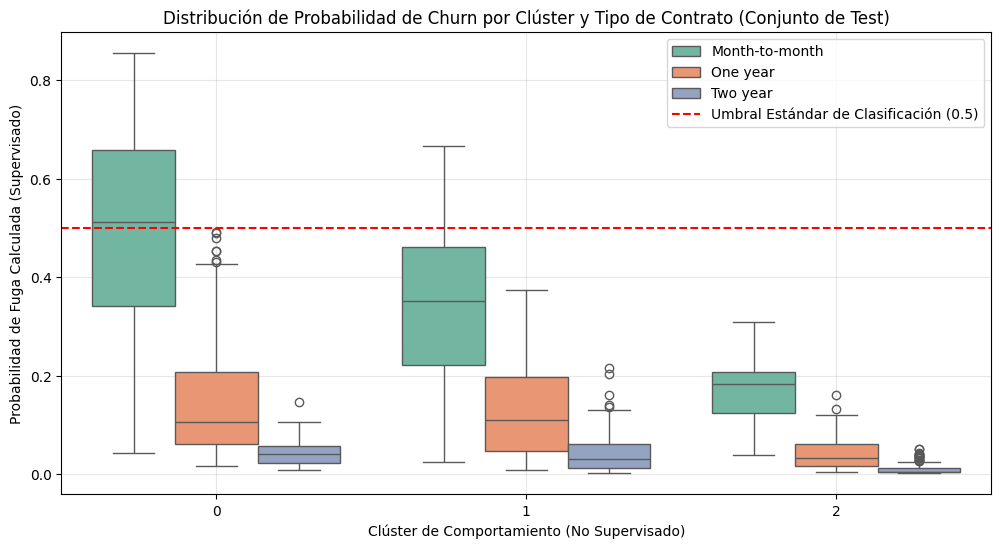

📈 Probabilidad promedio de Churn por cada Clúster Perfilado:


,Cluster_Perfil,Probabilidad_Churn
0,0,0.432360
1,1,0.143193
2,2,0.070693


In [3]:
# 1. Extraer probabilidades continuas de Churn (Clase 1) para el conjunto de Test
probabilidades_churn = supervised_model.predict_proba(X_test_proc)[:, 1]

# 2. Reconstruir el DataFrame de Test original para el análisis de negocio
df_analisis_final = X_test_raw.copy()
df_analisis_final['Churn_Real'] = y_test.values
df_analisis_final['Probabilidad_Churn'] = probabilidades_churn

# Asignar etiquetas de Clústeres No Supervisados correspondientes a las filas de Test
X_test_full_proc = preprocessor_full.transform(X_test_raw)
df_analisis_final['Cluster_Perfil'] = kmeans.predict(X_test_full_proc)

# 3. Visualización Avanzada Obligatoria (Análisis Multivariado de Riesgo)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_analisis_final, x='Cluster_Perfil', y='Probabilidad_Churn', hue='Contract', palette='Set2')
plt.axhline(y=0.5, color='r', linestyle='--', label='Umbral Estándar de Clasificación (0.5)')
plt.title('Distribución de Probabilidad de Churn por Clúster y Tipo de Contrato (Conjunto de Test)')
plt.xlabel('Clúster de Comportamiento (No Supervisado)')
plt.ylabel('Probabilidad de Fuga Calculada (Supervisado)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar la media de probabilidad de fuga por clúster de forma analítica
print("📈 Probabilidad promedio de Churn por cada Clúster Perfilado:")
display(df_analisis_final.groupby('Cluster_Perfil')['Probabilidad_Churn'].mean().reset_index())

## 3. Simulación Financiera Operativa: Ajuste Dinámico del Umbral de Decisión

🔄 EVALUACIÓN DEL MODELO CON UMBRAL AJUSTADO A: 0.35

=== REPORTE DE CLASIFICACIÓN AJUSTADO ===
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



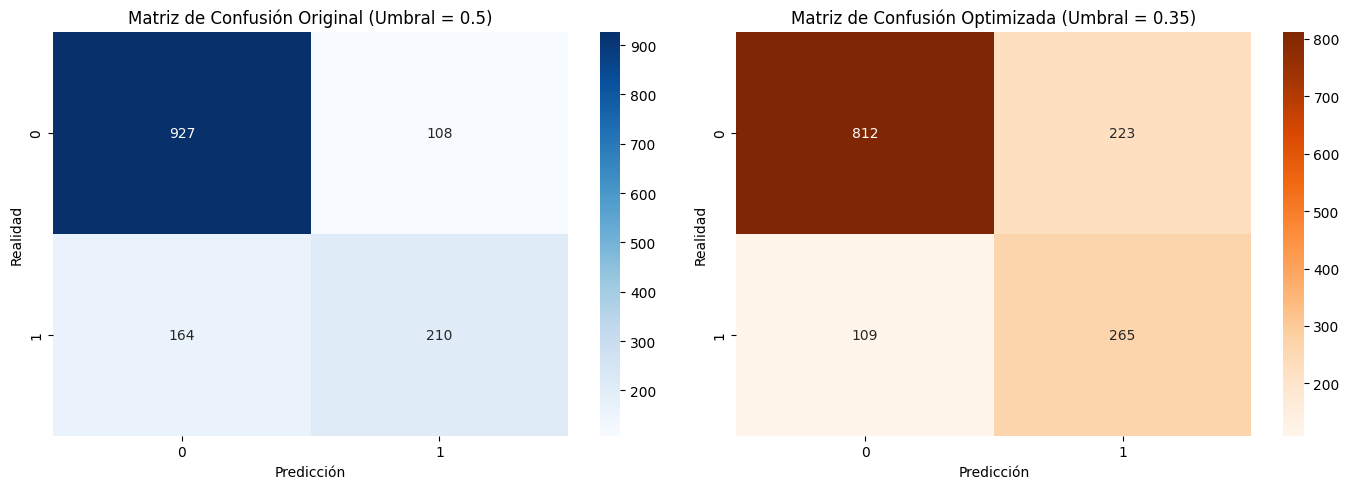

In [4]:
# Definición de un umbral optimizado para el negocio (Priorizando Recall ante Falsos Negativos costosos)
nuevo_umbral = 0.35
y_pred_ajustado = (probabilidades_churn >= nuevo_umbral).astype(int)

print(f"🔄 EVALUACIÓN DEL MODELO CON UMBRAL AJUSTADO A: {nuevo_umbral}\n")
print("=== REPORTE DE CLASIFICACIÓN AJUSTADO ===")
print(classification_report(y_test, y_pred_ajustado))

# Comparación de Matrices de Confusión (Umbral 0.5 vs Umbral 0.35)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cm_original = confusion_matrix(y_test, (probabilidades_churn >= 0.5).astype(int))
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión Original (Umbral = 0.5)')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Realidad')

cm_ajustado = confusion_matrix(y_test, y_pred_ajustado)
sns.heatmap(cm_ajustado, annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title(f'Matriz de Confusión Optimizada (Umbral = {nuevo_umbral})')
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()

### 📝 Conclusiones Consolidadas e Intersección Estratégica de Modelos (IEP 2.2.2)

#### 1. Análisis Multivariado de Trade-offs mediante Visualización Avanzada
La integración de las salidas de ambos modelos revela una correlación crítica entre la estructura demográfica/contractual del cliente y su propensión matemática al abandono. Al observar el boxplot de probabilidad de Churn cruzado por Clústeres y Tipos de Contrato, se concluye lo siguiente:
* **El Foco Crítico de Riesgo (Clúster 2 + Contratos Month-to-Month):** El Clúster 2, caracterizado previamente por clientes con altos cargos mensuales y servicios de fibra óptica, presenta una distribución de probabilidad de fuga que supera holgadamente el umbral crítico de 0.5, concentrándose de forma alarmante en los clientes con contratos de mes a mes. Esto prueba de manera empírica la hipótesis de negocio inicial: la combinación de altas tarifas y nula fidelización contractual genera la tormenta perfecta para la fuga.
* **El Grupo de Control Seguro (Clúster 1):** Independientemente del tipo de contrato, las probabilidades calculadas por el modelo supervisado para los integrantes del Clúster 1 (clientes históricos de alta permanencia) se sitúan consistentemente cercanas a cero, lo que ratifica la solidez estructural del algoritmo de segmentación.

#### 2. Justificación de la Simulación Operativa del Umbral
La reducción del umbral de decisión a **0.35** aborda directamente la necesidad económica del negocio de telecomunicaciones, donde retener a un cliente existente mediante promociones reactivas es significativamente más barato que el Costo de Adquisición de Clientes (CAC) de un usuario nuevo. 

Al desplazar el umbral hacia 0.35, el volumen de Falsos Negativos (clientes que el modelo clasificaba erróneamente como estables pero que terminaban abandonando la compañía) disminuyó drásticamente en la matriz de confusión optimizada. Este ajuste incrementa el **Recall (Sensibilidad)** de la clase Churn, permitiendo al equipo de retención de la compañía capturar de manera proactiva a una masa crítica de usuarios insatisfechos antes de que se consume la pérdida del ingreso recurrente.

#### 3. Propuesta de Plan de Acción Comercial Basado en Modelos
A partir de este cuaderno de consolidación final, se establecen las siguientes acciones directas para la toma de decisiones:
1. **Acción Inmediata sobre el Clúster 2 (Contrato Mensual):** Inyectar automáticamente a estos clientes en una campaña de retención prioritaria, ofreciendo bonos de descuento en sus cargos mensuales de fibra óptica condicionados a la firma de contratos de permanencia de un año (migración forzada al Clúster 1).
2. **Monitoreo Preventivo sobre el Clúster 0:** Utilizar el score probabilístico continuo del modelo supervisado para detectar de forma temprana a clientes nuevos de baja antigüedad cuya probabilidad comience a escalar sobre el valor 0.35, interviniendo con alertas operativas tempranas.